# BL-PINN —— Setting A (Abaid–Eisenberg–Liu, 1:−1)

$$\varepsilon^2\phi''=-(c_1-c_2),\qquad c_1'+c_1\phi'=-J_1,\qquad c_2'-c_2\phi'=-J_2$$

| | |
|---|---|
| 离子 | $n=2$, $\alpha_1=-\alpha_2=1$ |
| 通道 | $h\equiv1$,  永久电荷 $Q\equiv0$ |
| 边界条件 | $V=1$, $L_1=1.0$, $L_2=2.0$, $R_1=1.5$, $R_2=1.0$ |
| 摄动参数 | $\varepsilon=10^{-2}$ |

参考解由 `scipy.integrate.solve_bvp` 直接求解完整 PNP 系统给出, 作为统一评价基准。
所有方法共用同一套评估网格与误差指标 (第 8 节)。


## 1. 导入库和设置


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp as scipy_bvp, trapezoid
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.ticker import FormatStrFormatter
import time, copy

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

Device: cuda


## 2. 边界条件与辅助函数


In [2]:
def make_mlp(in_dim, out_dim, hidden=64, layers=4):
    net = [nn.Linear(in_dim, hidden), nn.SiLU()]
    for _ in range(layers - 1):
        net.extend([nn.Linear(hidden, hidden), nn.SiLU()])
    net.append(nn.Linear(hidden, out_dim))
    return nn.Sequential(*net)


def grad(y, x):
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True
    )[0]


def get_all_parameters(model):
    params = []
    for net in model['nets'].values():
        params.extend(net.parameters())
    params.extend(model['flux_params'])
    return params


def get_flux(model):
    return model['flux_params'][0].item(), model['flux_params'][1].item()

## 3. BL-PINN 模型


In [3]:
def create_blpinn(eps, hidden=55, layers=5, device=DEVICE):
    xi_max = 15.0

    model = {
        'eps': eps, 'xi_max': xi_max, 'device': device,
        'nets': {}, 'flux_params': []
    }

    # Outer network: x -> (phi0, c0)  [c10 = c20 = c0 by electroneutrality]
    model['nets']['outer'] = make_mlp(1, 2, hidden, layers).to(device)

    # Left inner network: xi -> (Phi0, C10, C20)  [eps-free inner equations]
    model['nets']['inner_left'] = make_mlp(1, 3, hidden, layers).to(device)

    # Right inner network: eta -> (Psi0, D10, D20)
    model['nets']['inner_right'] = make_mlp(1, 3, hidden, layers).to(device)

    # Shared flux parameters
    model['flux_params'].append(nn.Parameter(torch.tensor([0.1], device=device)))  # J1
    model['flux_params'].append(nn.Parameter(torch.tensor([0.1], device=device)))  # J2

    for net in model['nets'].values():
        for m in net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    return model


def eval_outer(model, x):
    """x in [0,1] -> (phi0, c0).  c10 = c20 = c0."""
    x_norm = 2.0 * x - 1.0
    out = model['nets']['outer'](x_norm)
    phi0 = out[:, 0:1]
    c0 = nn.functional.softplus(out[:, 1:2]) + 0.01
    return phi0, c0


def eval_inner_left(model, xi):
    """xi in [0, xi_max] -> (Phi0, C10, C20)"""
    xi_norm = 2.0 * xi / model['xi_max'] - 1.0
    out = model['nets']['inner_left'](xi_norm)
    Phi0 = out[:, 0:1]
    C10 = nn.functional.softplus(out[:, 1:2]) + 0.01
    C20 = nn.functional.softplus(out[:, 2:3]) + 0.01
    return Phi0, C10, C20


def eval_inner_right(model, eta):
    """eta in [-xi_max, 0] -> (Psi0, D10, D20)"""
    eta_norm = 2.0 * (eta + model['xi_max']) / model['xi_max'] - 1.0
    out = model['nets']['inner_right'](eta_norm)
    Psi0 = out[:, 0:1]
    D10 = nn.functional.softplus(out[:, 1:2]) + 0.01
    D20 = nn.functional.softplus(out[:, 2:3]) + 0.01
    return Psi0, D10, D20

## 4. 损失函数


In [4]:
def outer_pde_residual(model, x):
    """Outer PDE residual (Setting A: 1:-1)"""
    J1, J2 = model['flux_params']
    phi0, c0 = eval_outer(model, x)
    dphi0 = grad(phi0, x)
    dc0 = grad(c0, x)
    res1 = dc0 + c0 * dphi0 + J1     # NP for species 1
    res2 = dc0 - c0 * dphi0 + J2     # NP for species 2
    return torch.mean(res1**2 + res2**2)


def inner_left_pde_residual(model, xi):
    """Inner left PDE residual (eps-free equations in xi-coordinate)"""
    Phi0, C10, C20 = eval_inner_left(model, xi)
    dPhi0 = grad(Phi0, xi)
    d2Phi0 = grad(dPhi0, xi)
    dC10 = grad(C10, xi)
    dC20 = grad(C20, xi)
    res_P = d2Phi0 + (C10 - C20)       # Poisson (no eps!)
    res_1 = dC10 + C10 * dPhi0         # NP species 1
    res_2 = dC20 - C20 * dPhi0         # NP species 2
    return torch.mean(res_P**2 + res_1**2 + res_2**2)


def inner_right_pde_residual(model, eta):
    """Inner right PDE residual"""
    Psi0, D10, D20 = eval_inner_right(model, eta)
    dPsi0 = grad(Psi0, eta)
    d2Psi0 = grad(dPsi0, eta)
    dD10 = grad(D10, eta)
    dD20 = grad(D20, eta)
    res_P = d2Psi0 + (D10 - D20)
    res_1 = dD10 + D10 * dPsi0
    res_2 = dD20 - D20 * dPsi0
    return torch.mean(res_P**2 + res_1**2 + res_2**2)


def compute_loss(model, V, L1, L2, R1, R2):
    device = model['device']
    xi_max = model['xi_max']

    # --- PDE residuals ---
    x_o = torch.rand(150, 1, device=device).requires_grad_(True)
    loss_outer = outer_pde_residual(model, x_o)

    xi_L = (torch.rand(200, 1, device=device) * xi_max).requires_grad_(True)
    loss_inner_L = inner_left_pde_residual(model, xi_L)

    eta_R = (-torch.rand(150, 1, device=device) * xi_max).requires_grad_(True)
    loss_inner_R = inner_right_pde_residual(model, eta_R)

    # --- Inner boundary conditions ---
    xi0 = torch.zeros(1, 1, device=device, requires_grad=True)
    Phi0_0, C10_0, C20_0 = eval_inner_left(model, xi0)
    loss_bc_L = ((Phi0_0 - V)**2 + (C10_0 - L1)**2 + (C20_0 - L2)**2).mean()

    eta0 = torch.zeros(1, 1, device=device, requires_grad=True)
    Psi0_0, D10_0, D20_0 = eval_inner_right(model, eta0)
    loss_bc_R = ((Psi0_0 - 0.0)**2 + (D10_0 - R1)**2 + (D20_0 - R2)**2).mean()

    loss_bc = loss_bc_L + loss_bc_R

    # --- Prandtl matching conditions ---
    xi_far = torch.tensor([[xi_max]], device=device, requires_grad=True)
    Phi0_f, C10_f, C20_f = eval_inner_left(model, xi_far)

    x0 = torch.zeros(1, 1, device=device, requires_grad=True)
    phi0_at0, c0_at0 = eval_outer(model, x0)

    loss_m_L = ((Phi0_f - phi0_at0)**2 + (C10_f - c0_at0)**2 + (C20_f - c0_at0)**2).mean()

    eta_far = torch.tensor([[-xi_max]], device=device, requires_grad=True)
    Psi0_f, D10_f, D20_f = eval_inner_right(model, eta_far)

    x1 = torch.ones(1, 1, device=device, requires_grad=True)
    phi0_at1, c0_at1 = eval_outer(model, x1)

    loss_m_R = ((Psi0_f - phi0_at1)**2 + (D10_f - c0_at1)**2 + (D20_f - c0_at1)**2).mean()

    loss_match = loss_m_L + loss_m_R

    # --- Far-field derivative decay ---
    dPhi_f = grad(Phi0_f, xi_far); dC10_f = grad(C10_f, xi_far); dC20_f = grad(C20_f, xi_far)
    dPsi_f = grad(Psi0_f, eta_far); dD10_f = grad(D10_f, eta_far); dD20_f = grad(D20_f, eta_far)
    loss_decay = (dPhi_f**2 + dC10_f**2 + dC20_f**2 + dPsi_f**2 + dD10_f**2 + dD20_f**2).mean()

    total = loss_outer + loss_inner_L + loss_inner_R + 50*loss_bc + 10*loss_match + 5*loss_decay

    details = {'outer': loss_outer.item(), 'inner_L': loss_inner_L.item(),
               'inner_R': loss_inner_R.item(), 'bc': loss_bc.item(),
               'match': loss_match.item(), 'decay': loss_decay.item()}
    return total, details

## 5. 训练函数


In [5]:
def stitched_solution(model, x_np):

    device = model['device']
    eps = model['eps']
    xi_max = model['xi_max']

    x_L = eps * xi_max          # 左交界点
    x_R = 1.0 - eps * xi_max    # 右交界点

    # 分区掩码
    mask_left  = x_np < x_L
    mask_right = x_np > x_R
    mask_outer = ~mask_left & ~mask_right

    # 初始化输出
    phi_out = np.zeros_like(x_np)
    c1_out  = np.zeros_like(x_np)
    c2_out  = np.zeros_like(x_np)

    with torch.no_grad():
        # ---- 左边界层区域: 直接用 inner_left(ξ = x/ε) ----
        if np.any(mask_left):
            x_left = x_np[mask_left]
            xi = torch.tensor((x_left / eps).reshape(-1, 1),
                              dtype=torch.float32, device=device)
            Phi0, C10, C20 = eval_inner_left(model, xi)
            phi_out[mask_left] = Phi0.cpu().numpy().flatten()
            c1_out[mask_left]  = C10.cpu().numpy().flatten()
            c2_out[mask_left]  = C20.cpu().numpy().flatten()

        # ---- 外区域: 直接用 outer(x) ----
        if np.any(mask_outer):
            x_mid = x_np[mask_outer]
            x_t = torch.tensor(x_mid.reshape(-1, 1),
                               dtype=torch.float32, device=device)
            phi0, c0 = eval_outer(model, x_t)
            phi_out[mask_outer] = phi0.cpu().numpy().flatten()
            c1_out[mask_outer]  = c0.cpu().numpy().flatten()   # c1 = c2 = c0 (电中性)
            c2_out[mask_outer]  = c0.cpu().numpy().flatten()

        # ---- 右边界层区域: 直接用 inner_right(η = (x-1)/ε) ----
        if np.any(mask_right):
            x_right = x_np[mask_right]
            eta = torch.tensor(((x_right - 1.0) / eps).reshape(-1, 1),
                               dtype=torch.float32, device=device)
            Psi0, D10, D20 = eval_inner_right(model, eta)
            phi_out[mask_right] = Psi0.cpu().numpy().flatten()
            c1_out[mask_right]  = D10.cpu().numpy().flatten()
            c2_out[mask_right]  = D20.cpu().numpy().flatten()

    return phi_out, c1_out, c2_out


def train(model, V, L1, L2, R1, R2, epochs=150000, log_interval=500):
    params = get_all_parameters(model)
    optimizer = torch.optim.Adam(params, lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs, eta_min=1e-6)

    history = {'loss': [], 'J1': [], 'J2': []}
    best_loss = float('inf')
    best_state = [p.data.clone() for p in params]

    for ep in range(epochs):
        optimizer.zero_grad()
        loss, details = compute_loss(model, V, L1, L2, R1, R2)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        optimizer.step()
        scheduler.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = [p.data.clone() for p in params]

        J1, J2 = get_flux(model)
        history['loss'].append(loss.item())
        history['J1'].append(J1)
        history['J2'].append(J2)

        if (ep + 1) % log_interval == 0:
            d = details
            print(f"Epoch {ep+1:6d}/{epochs} | Loss: {loss.item():.4e} | "
                  f"J1={J1:.4f}, J2={J2:.4f} | "
                  f"pde_o={d['outer']:.2e} iL={d['inner_L']:.2e} "
                  f"match={d['match']:.2e} bc={d['bc']:.2e}")

    for p, b in zip(params, best_state):
        p.data.copy_(b)

    print(f"Training done! Best loss: {best_loss:.4e}")
    return history

## 6. 问题设置与单次训练


In [6]:
eps = 1e-2
V = 1.0
L1 = 1.0
L2 = 2.0
R1 = 1.5
R2 = 1.0

print(f"  BL-PINN (correct) for Setting A (1:-1)")
print(f"  eps = {eps}, V = {V}")
print(f"  Left BC: L1={L1}, L2={L2}")
print(f"  Right BC: R1={R1}, R2={R2}")

hidden = 55
epochs = 150000

model = create_blpinn(eps, hidden=hidden, layers=5, device=DEVICE)
param_count = sum(p.numel() for p in get_all_parameters(model))
print(f"Parameters: {param_count:,}")
print(f"xi_max = {model['xi_max']}")

import time

start_time = time.time()
history = train(model, V, L1, L2, R1, R2, epochs=epochs, log_interval=500)
end_time = time.time() # 记录结束时间

print(f"程序运行时间：{end_time - start_time} 秒")

  BL-PINN (correct) for Setting A (1:-1)
  eps = 0.01, V = 1.0
  Left BC: L1=1.0, L2=2.0
  Right BC: R1=1.5, R2=1.0
Parameters: 37,740
xi_max = 15.0
Epoch    500/150000 | Loss: 1.4035e-01 | J1=0.0198, J2=-0.0756 | pde_o=3.00e-06 iL=9.29e-02 match=3.72e-06 bc=1.85e-04
Epoch   1000/150000 | Loss: 4.4104e-01 | J1=0.0175, J2=-0.1274 | pde_o=4.11e-06 iL=6.48e-02 match=1.07e-04 bc=6.68e-03
Epoch   1500/150000 | Loss: 8.3150e-02 | J1=-0.0003, J2=-0.1657 | pde_o=3.08e-05 iL=5.19e-02 match=2.57e-05 bc=2.11e-04
Epoch   2000/150000 | Loss: 9.2725e-02 | J1=0.0038, J2=-0.1733 | pde_o=1.14e-06 iL=7.01e-02 match=2.27e-06 bc=1.85e-04
Epoch   2500/150000 | Loss: 5.5441e-02 | J1=0.0134, J2=-0.2323 | pde_o=1.23e-06 iL=3.52e-02 match=3.94e-06 bc=2.18e-04
Epoch   3000/150000 | Loss: 8.2078e-02 | J1=0.0479, J2=-0.2453 | pde_o=4.84e-06 iL=5.76e-02 match=1.85e-05 bc=2.93e-04
Epoch   3500/150000 | Loss: 7.2581e-02 | J1=0.0625, J2=-0.2292 | pde_o=8.57e-06 iL=4.39e-02 match=1.95e-04 bc=3.07e-04
Epoch   4000/1500

## 7. 精确参考解


In [7]:
def compute_exact_reference(eps, V, L1, L2, R1, R2, n_init=5000):
    c_L = np.sqrt(L1 * L2)
    c_R = np.sqrt(R1 * R2)
    phi_L = V + 0.5 * np.log(L1 / L2)
    phi_R = 0.5 * np.log(R1 / R2)
    M = 2 * c_L;  N = 2 * c_R
    T0 = 2 * (c_L - c_R)
    I0 = T0 * (phi_R - phi_L) / np.log(c_R / c_L) if abs(T0) > 1e-12 else 2*c_L*(phi_R-phi_L)
    J10, J20 = (I0+T0)/2, (T0-I0)/2
    l_p = (L2**0.25 - L1**0.25) / (L2**0.25 + L1**0.25)
    r_p = (R2**0.25 - R1**0.25) / (R2**0.25 + R1**0.25)

    x_init = np.linspace(0, 1, n_init)
    c0 = c_L - T0*x_init/2
    phi0 = phi_L + (I0/T0)*np.log(np.abs((M-T0*x_init)/M)) if abs(T0)>1e-12 else phi_L + I0*x_init/(2*c_L)

    xi = x_init/eps; eta = (x_init-1)/eps
    uL = l_p*np.exp(-np.sqrt(M)*np.minimum(xi,100))
    uR = r_p*np.exp(np.sqrt(N)*np.maximum(eta,-100))
    rpL = (1+uL)/np.maximum(np.abs(1-uL),1e-15)
    rpR = (1+uR)/np.maximum(np.abs(1-uR),1e-15)
    phi_g = phi0 + 2*np.log(np.abs(rpL)) + 2*np.log(np.abs(rpR))
    c1_g = np.maximum(c0 + (c_L/rpL**2-c_L) + (c_R/rpR**2-c_R), 0.01)
    c2_g = np.maximum(c0 + (c_L*rpL**2-c_L) + (c_R*rpR**2-c_R), 0.01)

    y0 = np.zeros((6, n_init))
    y0[0]=phi_g; y0[1]=np.gradient(phi_g,x_init); y0[2]=c1_g; y0[3]=c2_g; y0[4]=J10; y0[5]=J20

    def ode(x, y):
        phi,E,c1,c2,J1,J2 = y
        return np.vstack([E, -(c1-c2)/eps**2, -c1*E-J1, c2*E-J2, 0*x, 0*x])
    def bc(ya, yb):
        return np.array([ya[0]-V, yb[0], ya[2]-L1, yb[2]-R1, ya[3]-L2, yb[3]-R2])

    sol = scipy_bvp(ode, bc, x_init, y0, tol=1e-8, max_nodes=100000)
    assert sol.success, f'BVP failed: {sol.message}'
    return sol

## 8. 统一评估网格与误差指标


In [8]:
def create_evaluation_grid(eps, n_inner_per_side=2500, n_outer=200):
    """按论文方式创建分区评估网格"""
    bl_w = min(10 * eps, 0.05)  # 边界层宽度
    
    # 左边界层: [0, bl_w] 密集采点
    x_left_bl = np.linspace(0, bl_w, n_inner_per_side, endpoint=False)
    
    # 右边界层: [1-bl_w, 1] 密集采点
    x_right_bl = np.linspace(1 - bl_w, 1, n_inner_per_side, endpoint=True)
    
    # 交界点
    x_junction = np.array([bl_w, 1 - bl_w])
    
    # 外区域: (bl_w, 1-bl_w) 均匀采点
    x_outer = np.linspace(bl_w, 1 - bl_w, n_outer + 2)[1:-1]  # 去掉端点避免重复
    
    # 合并并排序
    x_all = np.sort(np.unique(np.concatenate([x_left_bl, x_right_bl, x_junction, x_outer])))
    
    # 记录各区域的索引掩码
    return {
        'x': x_all,
        'n': len(x_all),
        'bl_width': bl_w,
        'eps': eps,
        'mask_left_bl': x_all <= bl_w,
        'mask_right_bl': x_all >= 1 - bl_w,
        'mask_inner': (x_all <= bl_w) | (x_all >= 1 - bl_w),       # 所有边界层点
        'mask_outer': (x_all > bl_w) & (x_all < 1 - bl_w),          # 外区域
        'junction_left': np.argmin(np.abs(x_all - bl_w)),            # 左交界点索引
        'junction_right': np.argmin(np.abs(x_all - (1 - bl_w))),     # 右交界点索引
    }


def compute_unified_metrics(phi_a, c1_a, c2_a, J1_a, J2_a,
                            phi_e, c1_e, c2_e, J1_e, J2_e, grids):
    """
    按论文 Table 2 的五项指标评估:
    ① 全局相对 L²   ② 全局 L∞
    ③ 内区域相对 L²  ④ 内区域 L∞
    ⑤ 交界点误差
    """
    x = grids['x']
    mask_inner = grids['mask_inner']
    mask_left_bl = grids['mask_left_bl']
    mask_right_bl = grids['mask_right_bl']
    jL = grids['junction_left']
    jR = grids['junction_right']
    
    results = {}
    for name, ua, ue in [('phi', phi_a, phi_e), ('c1', c1_a, c1_e), ('c2', c2_a, c2_e)]:
        err = np.abs(ua - ue)
        
        # ① 全局相对 L²
        norm_e = np.sqrt(trapezoid(ue**2, x))
        norm_err = np.sqrt(trapezoid(err**2, x))
        global_rel_L2 = norm_err / max(norm_e, 1e-16)
        
        # ② 全局 L∞
        global_Linf = np.max(err)
        
        # ③ 内区域（边界层）相对 L²
        # 左右两段是不相连的区间，必须分别积分后相加。若直接对拼接后的节点
        # 数组调用 trapezoid，会在 w_BL 与 1-w_BL 之间多出一段宽度
        # (1-2*w_BL) 的伪梯形，分子分母同时被污染。
        def _int_sq(v, m):
            return trapezoid(v[m]**2, x[m]) if np.count_nonzero(m) > 1 else 0.0
        den_sq = _int_sq(ue, mask_left_bl) + _int_sq(ue, mask_right_bl)
        num_sq = _int_sq(err, mask_left_bl) + _int_sq(err, mask_right_bl)
        if den_sq > 0.0:
            inner_rel_L2 = np.sqrt(num_sq) / max(np.sqrt(den_sq), 1e-16)
        else:
            inner_rel_L2 = np.nan
        
        # ④ 内区域 L∞
        inner_Linf = np.max(err[mask_inner]) if np.any(mask_inner) else np.nan
        
        # ⑤ 交界点误差 (取左右交界点的最大误差)
        junction_err = max(err[jL], err[jR])
        
        results[name] = {
            'global_rel_L2': global_rel_L2,
            'global_Linf': global_Linf,
            'inner_rel_L2': inner_rel_L2,
            'inner_Linf': inner_Linf,
            'junction_err': junction_err,
        }
    
    # 通量和电流指标保持不变
    results['flux'] = {
        'J1_rel_err': abs(J1_a - J1_e) / max(abs(J1_e), 1e-16),
        'J2_rel_err': abs(J2_a - J2_e) / max(abs(J2_e), 1e-16),
    }
    I_a, I_e = J1_a - J2_a, J1_e - J2_e
    results['current'] = {
        'I_rel_err': abs(I_a - I_e) / max(abs(I_e), 1e-16),
        'I_approx': I_a, 'I_exact': I_e,
    }
    return results


def print_unified_table(metrics, method_name, eps):
    print(f'  统一评估: {method_name}  (ε = {eps})')
    print(f'  参考解: 完整 PNP 系统 scipy BVP 精确数值解')
    print(f"  {'指标':<22s} | {'phi':>12s} | {'c1':>12s} | {'c2':>12s}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    for mk, ml in [('global_rel_L2', '① 全局相对 L²'),
                    ('global_Linf',   '② 全局 L∞'),
                    ('inner_rel_L2',  '③ 内区域相对 L²'),
                    ('inner_Linf',    '④ 内区域 L∞'),
                    ('junction_err',  '⑤ 交界点误差')]:
        vals = [metrics[v][mk] for v in ['phi', 'c1', 'c2']]
        print(f"  {ml:<22s} | {vals[0]:>12.4e} | {vals[1]:>12.4e} | {vals[2]:>12.4e}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    print(f"\n  I_approx = {metrics['current']['I_approx']:.6f},  I_exact = {metrics['current']['I_exact']:.6f}")

def plot_vs_exact(x, phi_nn, c1_nn, c2_nn, phi_ex, c1_ex, c2_ex, eps, method_name):
    """统一绘图: NN解 vs 精确解 (3×2)"""
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    fig.suptitle(f'{method_name}  vs  Exact BVP  (ε={eps})', fontsize=14, fontweight='bold')

    # [0,0] 电势
    ax = axes[0,0]
    ax.plot(x, phi_ex, 'k-', lw=2.5, alpha=0.5, label='Exact BVP')
    ax.plot(x, phi_nn, 'r--', lw=2, label=method_name)
    ax.set(xlabel='x', ylabel='φ', title='Electric Potential'); ax.legend(); ax.grid(alpha=0.3)

    # [0,1] 浓度
    ax = axes[0,1]
    ax.plot(x, c1_ex, 'k-', lw=2.5, alpha=0.5, label='$c_1$ Exact')
    ax.plot(x, c2_ex, 'k:', lw=2.5, alpha=0.5, label='$c_2$ Exact')
    ax.plot(x, c1_nn, 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x, c2_nn, 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', ylabel='c', title='Concentrations'); ax.legend(); ax.grid(alpha=0.3)

    # [1,0] 左边界层
    ax = axes[1,0]; mask = x < 0.02
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Left BL (x<0.02)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [1,1] 右边界层
    ax = axes[1,1]; mask = x > 0.98
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Right BL (x>0.98)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,0] 逐点误差
    ax = axes[2,0]
    for var, u_nn, u_ex, c in [('φ', phi_nn, phi_ex, 'b'), ('c₁', c1_nn, c1_ex, 'r'), ('c₂', c2_nn, c2_ex, 'g')]:
        ax.semilogy(x, np.abs(u_nn - u_ex)+1e-16, c+'-', lw=1.5, label=var)
    ax.axhline(eps, color='gray', ls='--', alpha=0.5, label=f'ε={eps}')
    ax.axhline(eps**2, color='gray', ls=':', alpha=0.5, label=f'ε²={eps**2}')
    ax.set(xlabel='x', ylabel='|error|', title='Pointwise Error vs Exact BVP')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,1] 指标说明
    ax = axes[2,1]
    ax.text(0.5, 0.5, f'{method_name}\nThe unified evaluation indicators are shown in the table above.',
            ha='center', va='center', fontsize=14, transform=ax.transAxes)
    ax.axis('off')

    plt.tight_layout()
    plt.show()
    return fig

## 9. 单次评估


In [9]:
# 单次评估: 使用第 6 节训练好的 model
print('求解精确参考解 ...')
sol_exact = compute_exact_reference(eps, V, L1, L2, R1, R2)
grids = create_evaluation_grid(eps)
x_eval = grids['x']
y_ex = sol_exact.sol(x_eval)
phi_ex, c1_ex, c2_ex = y_ex[0], y_ex[2], y_ex[3]
J1_ex, J2_ex = y_ex[4, 0], y_ex[5, 0]
print(f'精确解通量: J1={J1_ex:.6f}, J2={J2_ex:.6f}, I={J1_ex-J2_ex:.6f}')

model_i = model
phi_nn, c1_nn, c2_nn = stitched_solution(model_i, x_eval)
J1_nn, J2_nn = get_flux(model_i)
print(f'NN 通量:     J1={J1_nn:.6f}, J2={J2_nn:.6f}, I={J1_nn-J2_nn:.6f}')

metrics = compute_unified_metrics(
    phi_nn, c1_nn, c2_nn, J1_nn, J2_nn,
    phi_ex, c1_ex, c2_ex, J1_ex, J2_ex, grids)
print_unified_table(metrics, 'BL-PINN', eps)

求解精确参考解 ...
精确解通量: J1=0.781933, J2=-0.404008, I=1.185941
NN 通量:     J1=0.783246, J2=-0.404014, I=1.187259
  统一评估: BL-PINN  (ε = 0.01)
  参考解: 完整 PNP 系统 scipy BVP 精确数值解
  指标                     |          phi |           c1 |           c2
  -----------------------+--------------+--------------+-------------
  ① 全局相对 L²              |   4.7571e-02 |   6.9827e-03 |   6.9686e-03
  ② 全局 L∞                |   7.0926e-02 |   2.9434e-02 |   2.9441e-02
  ③ 内区域相对 L²             |   2.5973e-02 |   4.3829e-03 |   4.2708e-03
  ④ 内区域 L∞               |   2.3951e-02 |   1.0773e-02 |   1.0675e-02
  ⑤ 交界点误差                |   2.3951e-02 |   1.0773e-02 |   1.0675e-02
  -----------------------+--------------+--------------+-------------

  I_approx = 1.187259,  I_exact = 1.185941


## 10. 可视化


In [ ]:
"""
plot_inset.py  —  带边界层放大嵌入图的可视化函数
替换原 notebook 中的 plot_vs_exact，将 c₁/c₂ 和边界层放大图合到同一张图中。
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ============================================================
# Colors matching the TikZ diagram palette
# ============================================================
BLUE    = '#1a56db'   # reference / c1 exact
RED     = '#c0392b'   # NN / c1 NN
GREEN   = '#00a050'   # c2 exact (or error φ)
PURPLE  = '#8c3cb4'   # c2 NN
ORANGE  = '#e67e22'   # error c2
BLUE_D  = '#0b2e7a'   # darker blue variant
GREEN_D = '#005c2e'   # darker green variant


def plot_with_inset(x, phi_nn, c1_nn, c2_nn, phi_ex, c1_ex, c2_ex,
                    eps, method_name,
                    bl_left=0.01, bl_right=0.990,
                    save_path=None):
    """
    生成两张图:
      图1: 电势 φ —— 主图 + 左/右边界层放大
      图2: 浓度 c₁, c₂ —— 主图 + 左/右边界层放大
    每张图的风格与 TikZ 通道示意图一致。

    参数:
        x            : 评估网格 (1-D array)
        phi_nn, ...  : NN 解
        phi_ex, ...  : 精确解
        eps          : Debye 长度参数
        method_name  : 图例标签
        bl_left      : 左边界层放大截止 x 值
        bl_right     : 右边界层放大起始 x 值
        save_path    : 若给出，保存 PNG/PDF
    """

    figs = []
    mask_L = x <= bl_left
    mask_R = x >= bl_right

    # helper: inset tick style
    def _style_inset(ins):
        ins.tick_params(labelsize=8, direction='in')
        ins.patch.set_alpha(0.95)

    # ================================================================
    #  图1: 电势 φ
    # ================================================================
    fig1, ax1 = plt.subplots(figsize=(8, 5.5))
    ax1.plot(x, phi_ex, color=BLUE, ls='-',  lw=2.2, label=r'$\phi$ Reference')
    ax1.plot(x, phi_nn, color=RED,  ls='--', lw=2.0, label=rf'$\phi$ {method_name}')
    ax1.set_xlabel(r'Position $x$')
    ax1.set_ylabel(r'Electric Potential $\phi$')
    ax1.legend(loc='upper right')

    # ---- 左边界层放大 ----
    if np.any(mask_L):
        ax_inL = ax1.inset_axes([0.2, 0.25, 0.15, 0.42])
        ax_inL.plot(x[mask_L], phi_ex[mask_L], color=BLUE, ls='-',  lw=2)
        ax_inL.plot(x[mask_L], phi_nn[mask_L], color=RED,  ls='--', lw=1.8)
        ax_inL.set_xlim(0, bl_left)
        ax_inL.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax_inL.set_xticks([0, bl_left])
        _style_inset(ax_inL)
        mark_inset(ax1, ax_inL, loc1=2, loc2=3, fc="0.9", ec="0.9", lw=0.8)

    # ---- 右边界层放大 ----
    if np.any(mask_R):
        ax_inR = ax1.inset_axes([0.65, 0.25, 0.15, 0.42])
        ax_inR.plot(x[mask_R], phi_ex[mask_R], color=BLUE, ls='-',  lw=2)
        ax_inR.plot(x[mask_R], phi_nn[mask_R], color=RED,  ls='--', lw=1.8)
        ax_inR.set_xlim(bl_right, 1)
        ax_inR.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        _style_inset(ax_inR)
        mark_inset(ax1, ax_inR, loc1=1, loc2=4, fc="0.9", ec="0.9", lw=0.8)

    fig1.tight_layout()
    figs.append(fig1)

    # ================================================================
    #  图2: 浓度 c₁, c₂
    # ================================================================
    fig2, ax2 = plt.subplots(figsize=(8, 5.5))
    ax2.plot(x, c1_ex, color=BLUE,   ls='-',  lw=2.2, label=r'$c_1$ Reference')
    ax2.plot(x, c2_ex, color=GREEN,  ls='-',  lw=2.2, label=r'$c_2$ Reference')
    ax2.plot(x, c1_nn, color=BLUE_D, ls='--', lw=2.0, label=rf'$c_1$ {method_name}')
    ax2.plot(x, c2_nn, color=PURPLE, ls='--', lw=2.0, label=rf'$c_2$ {method_name}')
    ax2.set_xlabel(r'Position $x$')
    ax2.set_ylabel('Ion Concentration')
    ax2.legend(loc='best')

    # ---- 左边界层放大 ----
    if np.any(mask_L):
        ax_cL = ax2.inset_axes([0.2, 0.25, 0.15, 0.42])
        ax_cL.plot(x[mask_L], c1_ex[mask_L], color=BLUE,   ls='-',  lw=2)
        ax_cL.plot(x[mask_L], c2_ex[mask_L], color=GREEN,  ls='-',  lw=2)
        ax_cL.plot(x[mask_L], c1_nn[mask_L], color=BLUE_D, ls='--', lw=1.8)
        ax_cL.plot(x[mask_L], c2_nn[mask_L], color=PURPLE, ls='--', lw=1.8)
        ax_cL.set_xlim(0, bl_left)
        ax_cL.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax_cL.set_xticks([0, bl_left])
        _style_inset(ax_cL)
        mark_inset(ax2, ax_cL, loc1=2, loc2=3, fc="0.9", ec="0.9", lw=0.8)

    # ---- 右边界层放大 ----
    if np.any(mask_R):
        ax_cR = ax2.inset_axes([0.65, 0.25, 0.15, 0.42])
        ax_cR.plot(x[mask_R], c1_ex[mask_R], color=BLUE,   ls='-',  lw=2)
        ax_cR.plot(x[mask_R], c2_ex[mask_R], color=GREEN,  ls='-',  lw=2)
        ax_cR.plot(x[mask_R], c1_nn[mask_R], color=BLUE_D, ls='--', lw=1.8)
        ax_cR.plot(x[mask_R], c2_nn[mask_R], color=PURPLE, ls='--', lw=1.8)
        ax_cR.set_xlim(bl_right, 1)
        ax_cR.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        _style_inset(ax_cR)
        mark_inset(ax2, ax_cR, loc1=1, loc2=4, fc="0.9", ec="0.9", lw=0.8)

    fig2.tight_layout()
    figs.append(fig2)

    # ================================================================
    #  图3: 逐点误差 (semilogy)
    # ================================================================
    fig3, ax3 = plt.subplots(figsize=(8, 5))
    for var, u_nn, u_ex, clr in [(r'$\phi$', phi_nn, phi_ex, BLUE),
                                  (r'$c_1$', c1_nn,  c1_ex,  RED),
                                  (r'$c_2$', c2_nn,  c2_ex,  GREEN)]:
        ax3.semilogy(x, np.abs(u_nn - u_ex) + 1e-16, color=clr, ls='-',
                     lw=1.5, label=var)
    ax3.axhline(eps,    color='gray', ls='--', alpha=0.6,
                label=rf'$\varepsilon={eps}$')
    ax3.axhline(eps**2, color='gray', ls=':',  alpha=0.6,
                label=rf'$\varepsilon^2={eps**2}$')
    ax3.set_xlabel(r'Position $x$')
    ax3.set_ylabel(r'$|$error$|$')
    ax3.set_title(rf'Pointwise Error  ({method_name} vs Exact BVP)',
                  fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    fig3.tight_layout()
    figs.append(fig3)

    # ---- 保存 ----
    if save_path:
        names = ['phi', 'concentration', 'error']
        for i, fig in enumerate(figs):
            fig.savefig(f'{save_path}_{names[i]}.pdf', bbox_inches='tight')
            fig.savefig(f'{save_path}_{names[i]}.png', bbox_inches='tight')

    plt.show()
    return figs

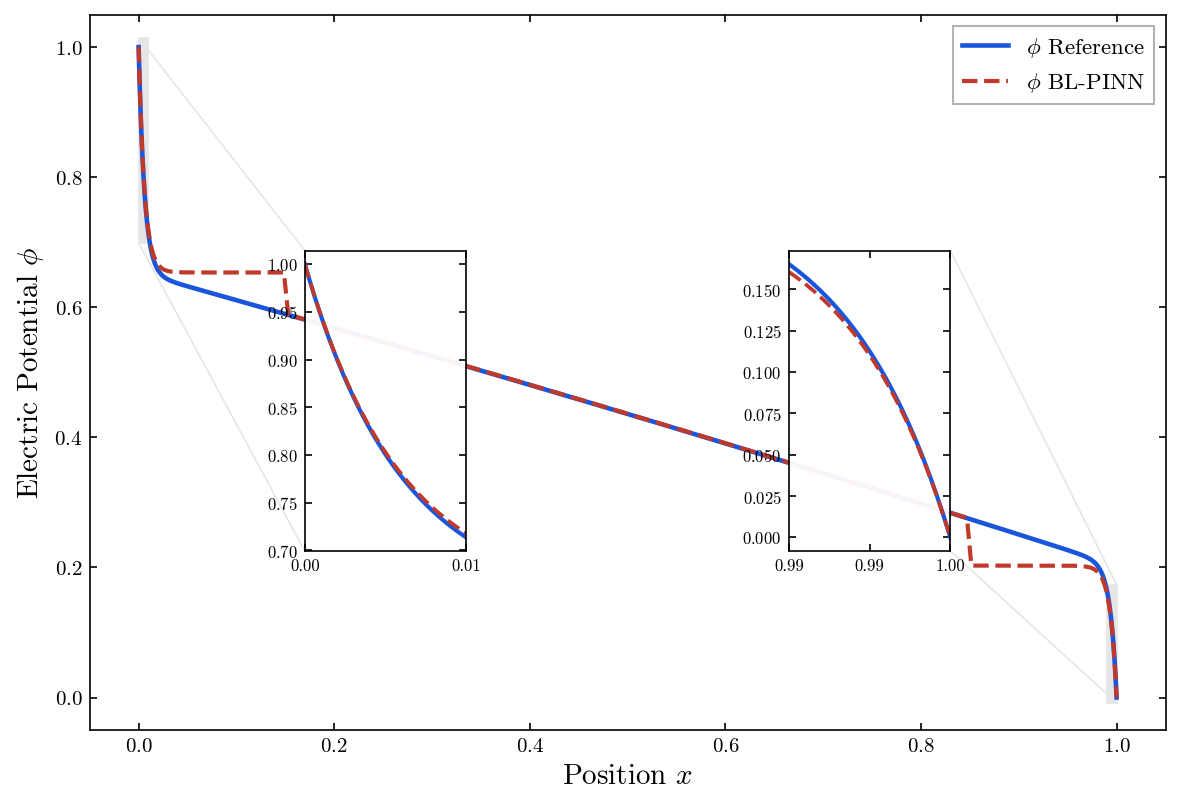

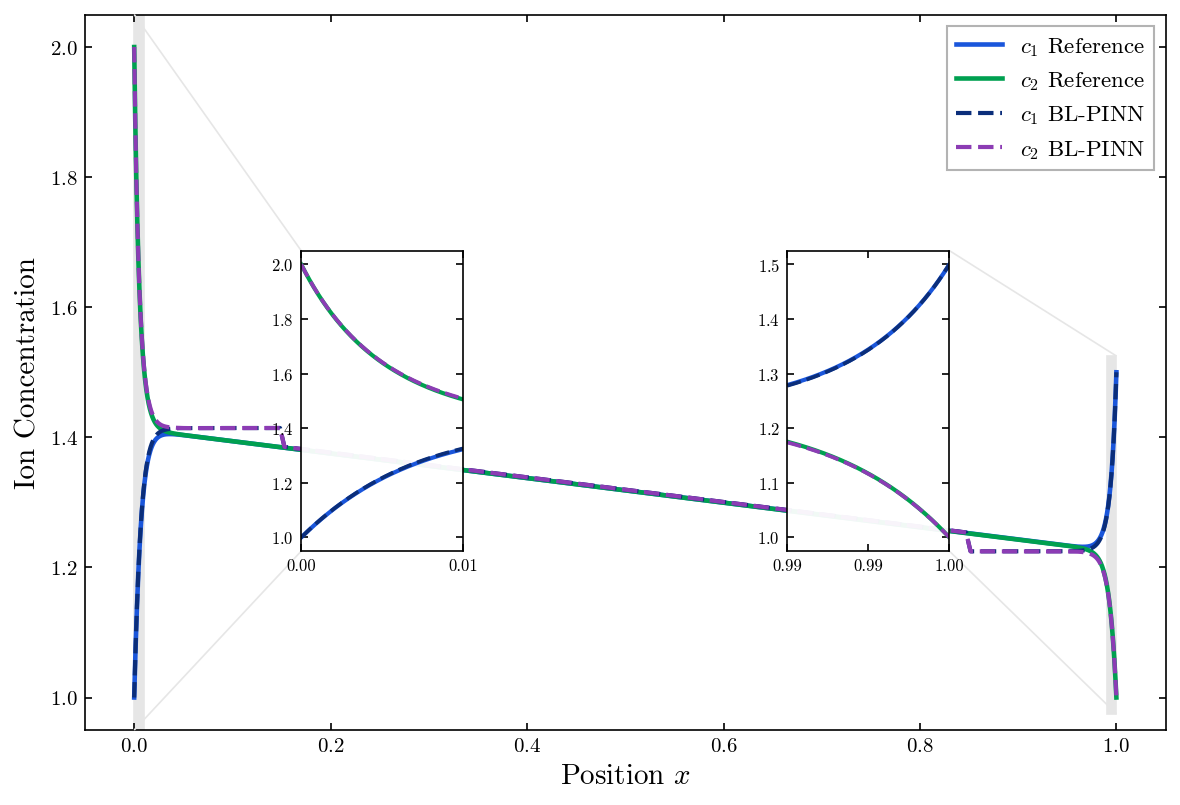

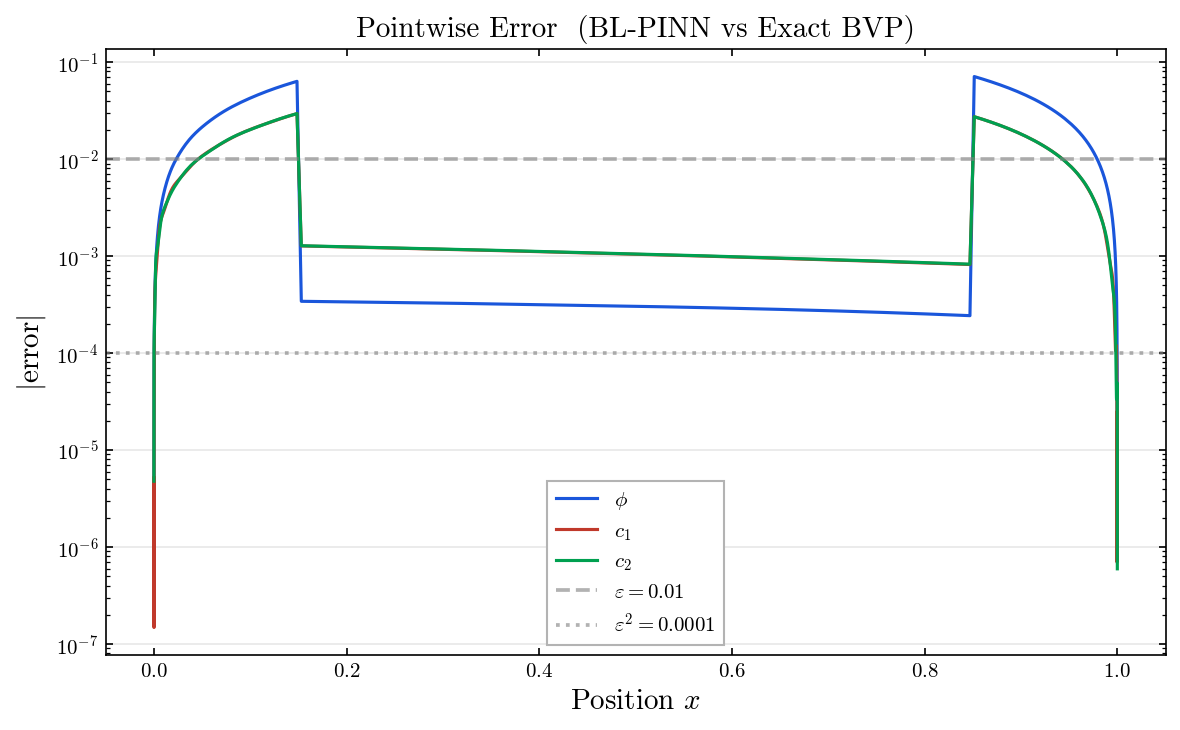

In [11]:
figs = plot_with_inset(x_eval, phi_nn, c1_nn, c2_nn,
                       phi_ex, c1_ex, c2_ex, eps, 'BL-PINN')

## 11. 五次独立实验 (固定随机种子)


# ============================================================
#  五次独立实验 (固定随机种子, 报告 mean ± std)
# ============================================================
import copy, time

SEEDS = [0, 1, 2, 3, 4]          # 固定随机种子, 保证可复现
N_RUNS = len(SEEDS)

# ---- 精确解只算一次 ----
print('求解精确参考解 ...')
sol_exact = compute_exact_reference(eps, V, L1, L2, R1, R2)
grids = create_evaluation_grid(eps)
x_eval = grids['x']
y_ex = sol_exact.sol(x_eval)
phi_ex, c1_ex, c2_ex = y_ex[0], y_ex[2], y_ex[3]
J1_ex, J2_ex = y_ex[4, 0], y_ex[5, 0]
print(f'精确解通量: J1={J1_ex:.6f}, J2={J2_ex:.6f}, I={J1_ex-J2_ex:.6f}')

all_metrics, all_times = [], []

for run in range(N_RUNS):
    torch.manual_seed(SEEDS[run])
    np.random.seed(SEEDS[run])
    print(f'\n{"="*50}')
    print(f'  Run {run+1}/{N_RUNS}   (seed = {SEEDS[run]})')
    print(f'{"="*50}')
    t0 = time.time()

    model_i = create_blpinn(eps, hidden=55, layers=5, device=DEVICE)
    history_i = train(model_i, V, L1, L2, R1, R2,
                      epochs=150000, log_interval=30000)
    elapsed = time.time() - t0
    all_times.append(elapsed)

    phi_nn, c1_nn, c2_nn = stitched_solution(model_i, x_eval)
    J1_nn, J2_nn = get_flux(model_i)

    m = compute_unified_metrics(
        phi_nn, c1_nn, c2_nn, J1_nn, J2_nn,
        phi_ex, c1_ex, c2_ex, J1_ex, J2_ex, grids)
    all_metrics.append(m)
    print(f'  用时 {elapsed:.1f}s  |  全局相对L²(φ)={m["phi"]["global_rel_L2"]:.4e}')

print(f'\n全部 {N_RUNS} 次实验完成!')

# ---- 汇总统计 ----
metric_keys = ['global_rel_L2', 'global_Linf', 'inner_rel_L2',
               'inner_Linf', 'junction_err']
metric_labels = ['① 全局相对 L²', '② 全局 L∞', '③ 内区域相对 L²',
                 '④ 内区域 L∞', '⑤ 交界点误差']
var_names = ['phi', 'c1', 'c2']

print(f'\n{"="*80}')
print(f'  BL-PINN  {N_RUNS} 次随机实验统计  (Setting A, ε = {eps})')
print(f'{"="*80}')
print(f'{"指标":<22s} | {"phi (mean±std)":>24s} | {"c1 (mean±std)":>24s} | {"c2 (mean±std)":>24s}')
print(f'{"-"*22}-+-{"-"*24}-+-{"-"*24}-+-{"-"*24}')
for mk, ml in zip(metric_keys, metric_labels):
    row = []
    for v in var_names:
        vals = np.array([m[v][mk] for m in all_metrics])
        row.append(f'{vals.mean():.4e} ± {vals.std():.4e}')
    print(f'{ml:<22s} | {row[0]:>24s} | {row[1]:>24s} | {row[2]:>24s}')
print(f'{"-"*22}-+-{"-"*24}-+-{"-"*24}-+-{"-"*24}')
print(f'  训练用时: {np.mean(all_times):.1f} ± {np.std(all_times):.1f} s')